<a href="https://colab.research.google.com/github/cristianzucconi2-web/deep_learning/blob/main/(LLama_3_2_3B)NoFineTuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.17: Fast Llama patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

chat_template.jinja: 0.00B [00:00, ?B/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


🚀 Avvio Benchmark Llama-3.2 su 784 tweet...


  0%|          | 0/784 [00:00<?, ?it/s]Both `max_new_tokens` (=1) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, Fu


======= 📊 RISULTATI LLAMA-3.2-3B (ZERO-SHOT) =======
ACCURACY ATTUALE: 62.50%
ACCURACY FINE-TUNED (Tuo Riferimento): 83.16%
--------------------------------------------------

REPORT DI CLASSIFICAZIONE:
                 precision    recall  f1-score   support

Non Ironico (0)       0.64      0.86      0.73       473
    Ironico (1)       0.56      0.27      0.36       311

       accuracy                           0.62       784
      macro avg       0.60      0.56      0.55       784
   weighted avg       0.61      0.62      0.59       784



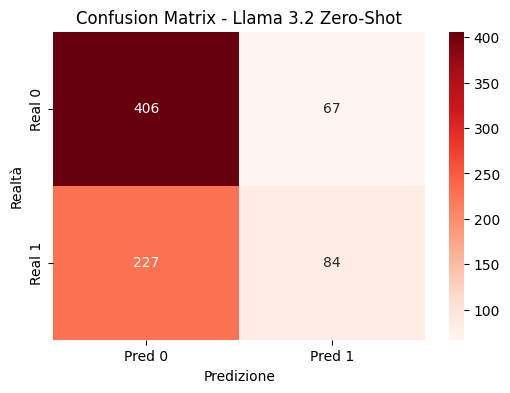

In [ ]:
# 1. INSTALLAZIONE E SETUP (Se non già fatta)
# !pip install unsloth

from unsloth import FastLanguageModel
import torch
import pandas as pd
import re
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 2. CARICAMENTO MODELLO LLAMA-3.2-3B (Base Instruct)
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-3B-Instruct",
    max_seq_length = 2048,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(model)

# 3. PREPARAZIONE DATASET
# Se la cartella non esiste, la cloniamo
import os
if not os.path.exists('SemEval2018-Task3'):
    !git clone https://github.com/Cyvhee/SemEval2018-Task3.git

path_test = 'SemEval2018-Task3/datasets/goldtest_TaskA/SemEval2018-T3_gold_test_taskA_emoji.txt'
test_df = pd.read_csv(path_test, sep='\t')

if 'tweet text' not in test_df.columns:
    test_df = pd.read_csv(path_test, sep='\t', header=None, names=['index', 'label', 'tweet text'])

# Pulizia e filtro
test_df_clean = test_df[test_df['label'].astype(str).str.contains('0|1')].copy()  # filtro il dataset per assicurarsi che ci siano solo etichette valide (0 o 1)

def clean_test(text):
    text = str(text)
    text = re.sub(r'http\S+|@\w+', '', text)
    return text.strip()

test_df_clean['tweet text'] = test_df_clean['tweet text'].apply(clean_test)
y_true = test_df_clean['label'].astype(int).values

# 4. ESECUZIONE BENCHMARK ZERO-SHOT
print(f" Avvio Benchmark Llama-3.2 su {len(test_df_clean)} tweet...")
predictions = []

for text in tqdm(test_df_clean['tweet text']):
    # Formato prompt specifico per Llama-3.2
    prompt = (
        f"<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\n"
        f"You are a linguistic expert. Is the tweet ironic? Answer ONLY with 1 (Yes) or 0 (No).<|eot_id|>"
        f"<|start_header_id|>user<|end_header_id|>\n\n"
        f"Tweet: {text}<|eot_id|>"
        f"<|start_header_id|>assistant<|end_header_id|>\n\n"
    )

    inputs = tokenizer([prompt], return_tensors = "pt").to("cuda") # trasformo le parole del prompt in numeri che la GPU può elaborare.

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens = 1,
            use_cache = False, # Disattivato per stabilità su T4
            pad_token_id = tokenizer.eos_token_id
        )

    # Decodifica solo l'ultimo token generato
    response = tokenizer.decode(outputs[0][-1:], skip_special_tokens=True).strip() #ritrasformo il numero generato in testo

    # Estrazione robusta dello 0 o 1
    digit = re.search(r'[01]', response)  #filtro la risposta di llama solo su 0 ed 1
    predictions.append(int(digit.group()) if digit else 0) # salvo il risultato su prediction

# 5. ANALISI DEI RISULTATI
acc_zero_shot = accuracy_score(y_true, predictions) # calcola la percentuale di risposte azzeccate.

print(f"\n======= RISULTATI LLAMA-3.2-3B (ZERO-SHOT) =======")
print(f"ACCURACY ATTUALE: {acc_zero_shot:.2%}")
print(f"ACCURACY FINE-TUNED (Tuo Riferimento): 83.16%")
print("-" * 50)

# Classification Report (Precision, Recall, F1)
print("\nREPORT DI CLASSIFICAZIONE:")
print(classification_report(y_true, predictions, target_names=['Non Ironico (0)', 'Ironico (1)']))

# Matrice di Confusione
cm = confusion_matrix(y_true, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['Real 0', 'Real 1'])
plt.title('Confusion Matrix - Llama 3.2 Zero-Shot')
plt.xlabel('Predizione')
plt.ylabel('Realtà')
plt.show()

227 (Falso Negativo - L'errore più grave): Tweet che erano REALI 1 (ironici) ma il modello ha detto PRED 0.

 Llama 3.2 è troppo ingenuo. Non ha capito l'ironia in ben 227 casi, prendendo il tweet alla lettera. È il motivo per cui la Recall dell'ironia era così bassa (27%).

67 (Falso Positivo): Tweet che erano REALI 0 (seri) ma il modello ha detto PRED 1.

Sono i falsi allarmi. Il modello ha visto ironia dove non c'era ma succede raramente rispetto all'altro errore.